# TP2 - Análise de Desempenho de Técnicas de Aprendizagem Automática
**Análise Discreta | ISEP 2025/2026**

**Turma 3DH - Grupo 8:** Mariana Martins 1230679 | Luna Gomes 1231651 | Samara Miranda 1230432

**Tema:** Impacto da Eficiência Energética na Iluminação Pública na Reserva de Potência dos PTDs e Viabilidade de Mobilidade Elétrica

---
### Continuidade com o TP1

O TP1 realizou uma análise estatística exploratória **ao nível do concelho**, definindo as seguintes métricas de engenharia que são usadas no TP2 ao nível do PTD individual:

| Variável TP1 | Fórmula (TP1) | Variável TP2 (PTD level) | Observação |
|---|---|---|---|
| Ganho LED (ΔP_LED) | `P_IP_Inef × 0.65` | `Ganho_LED_PTD` | Já calculado no dataset |
| Folga Rede (P_Folga) | `Cap_PTD × 0.92 × (1 − Util_Media)` | `PFolga_PTD` | Margem de segurança 92% |
| Carga VE (P_VE) | `N_PTDs × 22kW × 0.60` | `PVE_PTD = 13.2 kW` | Por PTD, fator simult. 60% |
| Saldo sem LED (D) | `P_Folga − P_VE` | `D_PTD` | Já calculado |
| Saldo com LED (D_LED) | `P_Folga + ΔP_LED − P_VE` | `D_PTD_LED` | Já calculado |
| Rate Ineficiência | `P_IP_Inef / P_IP_Total` | `Rate_Ineficiencia` | Já calculado |

**Contexto do TP1:** O modelo OLS (Regressão Linear Múltipla) obteve R²_adj = 6.4%, evidenciando que a análise agregada ao nível do concelho tem baixo poder explicativo - o que motiva a passagem para análise ao nível do PTD individual com técnicas de ML.

## Setup - Imports e Configuração

In [1]:
!pip install scikit-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import shapiro, ttest_rel, wilcoxon

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Setup concluído. TF:', tf.__version__)

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -----------

---
## 4.1. Análise Exploratória de Dados (EDA)
### 4.1.1 - Carregar dataset e sumário

In [2]:
df = pd.read_excel('PTD_level_dataset.xlsx')
print('Dimensão:', df.shape)
df.head()

Dimensão: (72027, 32)


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
# Sumário de nulos
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('Colunas com valores omissos:')
print(info_df[info_df['nulos'] > 0].to_string())
print('\nEstatísticas descritivas (variáveis chave do TP1 e TP2):')
key_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef',
            'Rate_Ineficiencia', 'LED_Ratio', 'Ganho_LED_PTD',
            'PFolga_PTD', 'PVE_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']
df[key_cols].describe().round(4)

Colunas com valores omissos:
                           dtype  nulos  nulos_%
Pot_Contratada_kVA       float64  21180    29.41
Pot_Geracao_kW           float64  70191    97.45
D_PTD                    float64   3064     4.25
D_PTD_LED                float64   3064     4.25
PContratada_per_Cliente  float64  21180    29.41
Geracao_per_Cliente      float64  70191    97.45
Util_Decimal             float64   3064     4.25
PFolga_PTD               float64   3064     4.25

Estatísticas descritivas (variáveis chave do TP1 e TP2):


,Cap_PTD_kVA,N_Clientes,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,Ganho_LED_PTD,PFolga_PTD,PVE_PTD,D_PTD,D_PTD_LED,Util_Decimal
count,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,68963.0000,72027.0,68963.0000,68963.0000,68963.0000
mean,302.7988,94.6980,1381.4902,463.2906,0.2807,0.6717,0.5569,147.9833,13.2,134.7833,135.3433,0.5138
std,294.4445,110.0551,1723.7106,708.0096,0.2404,0.2731,0.6874,186.7599,0.0,186.7599,186.8503,0.2470
min,0.0000,20.0000,23.2186,0.0000,0.0000,0.0117,0.0000,0.0000,13.2,-13.2000,-13.2000,0.1900
25%,100.0000,20.0000,382.5690,28.9850,0.0642,0.5007,0.0683,37.2600,13.2,24.0600,24.1603,0.3900
50%,250.0000,54.0000,842.1797,137.7200,0.2292,0.7196,0.3187,77.2800,13.2,64.0800,64.3775,0.3900
75%,400.0000,124.0000,1766.3913,625.7900,0.4474,0.9116,0.7623,224.4800,13.2,211.2800,211.3483,0.5900
max,8000.0000,1438.0000,9065.6553,3494.9200,0.9836,1.0000,3.5069,4489.6000,13.2,4476.4000,4479.2253,1.0000


**Verificação das fórmulas do TP1 no dataset TP2:**
- `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)` ✓
- `PVE_PTD = 22 × 0.60 = 13.2 kW` (constante por PTD) ✓
- `D_PTD = PFolga_PTD − PVE_PTD` ✓
- `D_PTD_LED = PFolga_PTD + Ganho_LED_PTD − PVE_PTD` ✓
- `Rate_Ineficiencia = P_IP_Inef / P_IP_Total` ✓

### 4.1.2 - Exploração visual

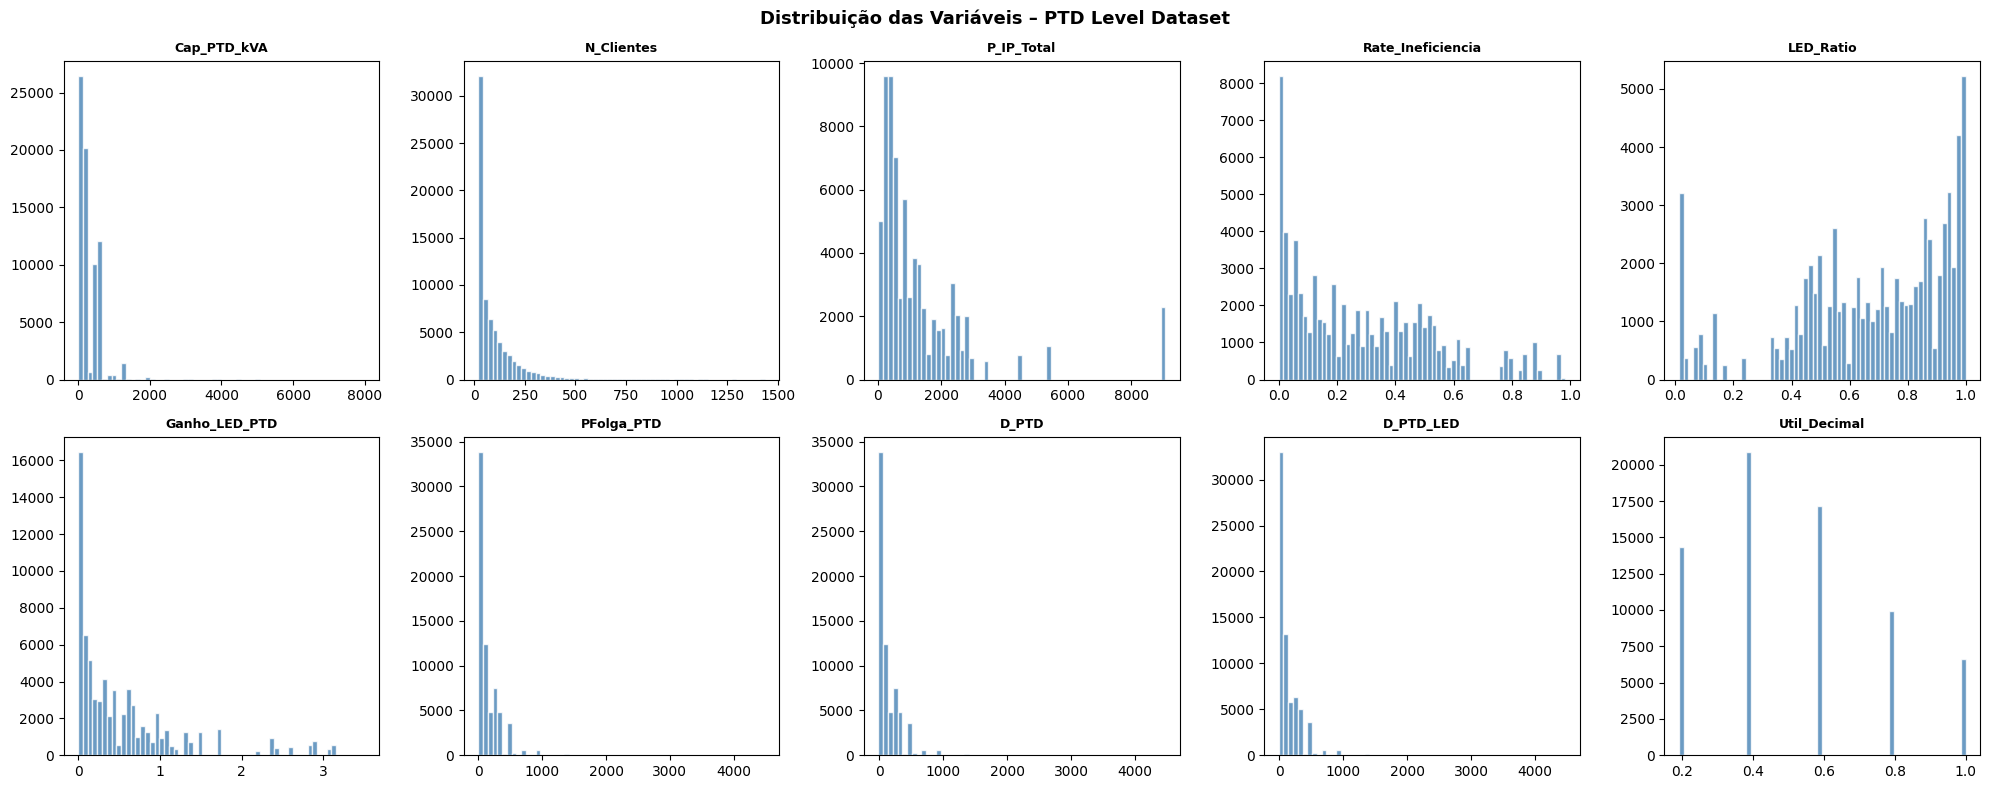

In [4]:
plot_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia',
             'LED_Ratio', 'Ganho_LED_PTD', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Distribuição das Variáveis – PTD Level Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()

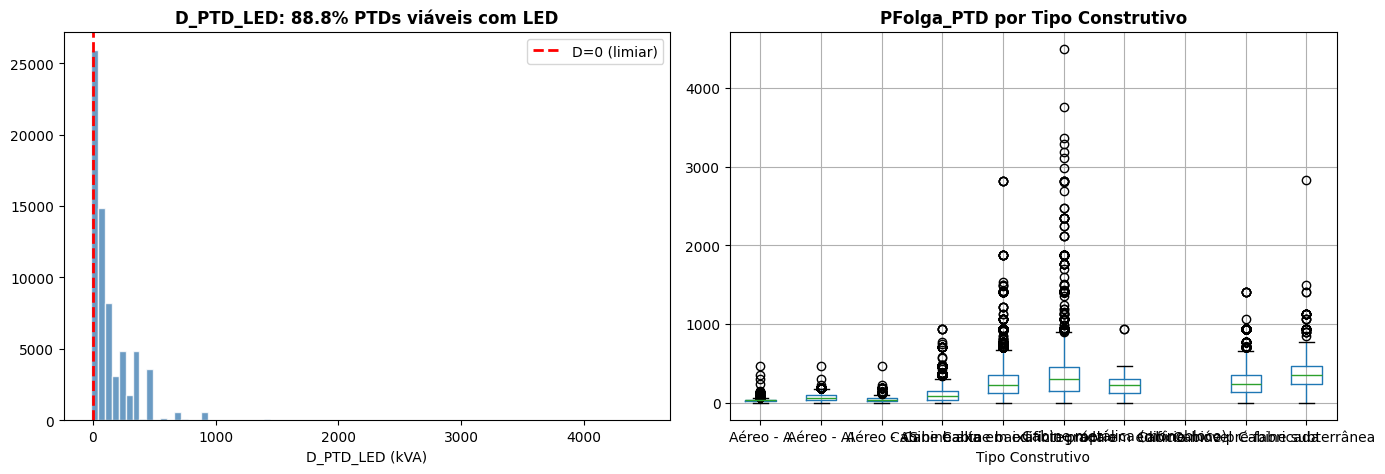

PTDs viáveis para VE com LED: 88.8%
PTDs viáveis para VE sem LED: 88.8%


In [5]:
# Análise de viabilidade para VE (continuidade com TP1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
d_led = df['D_PTD_LED'].dropna()
pct_led = (d_led > 0).mean() * 100
pct_sem = (df['D_PTD'].dropna() > 0).mean() * 100

axes[0].hist(d_led, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='D=0 (limiar)')
axes[0].set_title(f'D_PTD_LED: {pct_led:.1f}% PTDs viáveis com LED', fontweight='bold')
axes[0].set_xlabel('D_PTD_LED (kVA)')
axes[0].legend()

df.boxplot(column='PFolga_PTD', by='Tipo Construtivo', ax=axes[1])
axes[1].set_title('PFolga_PTD por Tipo Construtivo', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_viabilidade.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PTDs viáveis para VE com LED: {pct_led:.1f}%')
print(f'PTDs viáveis para VE sem LED: {pct_sem:.1f}%')

### 4.1.3 - Pré-processamento

In [6]:
# Remover colunas não adequadas para modelação
# Justificação de cada exclusão:
# - Identificadores/coordenadas: sem poder preditivo
# - 'Potência instalada [kVA]': redundante com Cap_PTD_kVA
# - 'Nível de Utilização [%]': string; Util_Decimal é a versão numérica
# - Pot_Geracao_kW e derivadas: 97.5% nulos
# - Geográficas (Distrito/Concelho/Cod): escala capturada por N_PTDs_Concelho
cols_drop = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    'Código de Instalação', 'Coordenadas Geográficas',
    'Potência instalada [kVA]', 'Nível de Utilização [%]',
    'Pot_Geracao_kW', 'N_Clientes_Produtores',
    'Geracao_per_Cliente', 'Clientes_Produtores_Ratio',
]
df_clean = df.drop(columns=cols_drop).copy()

# Imputação de Pot_Contratada_kVA (~29% nulos) pela mediana por Tipo Construtivo
# Justificação: PTDs do mesmo tipo têm perfis de contratação semelhantes
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Remover PTDs sem nível de utilização (4.3% do dataset)
df_clean = df_clean.dropna(subset=['PFolga_PTD', 'Util_Decimal'])

print('Dimensão após limpeza:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())

Dimensão após limpeza: (68963, 21)
Nulos restantes: 0


In [7]:
# Encoding de Tipo Construtivo
le = LabelEncoder()
df_clean['Tipo_Construtivo_enc'] = le.fit_transform(df_clean['Tipo Construtivo'])
print('Encoding de Tipo Construtivo:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Encoding de Tipo Construtivo:
  0 -> Aéreo - A
  1 -> Aéreo - AI
  2 -> Aéreo - AS
  3 -> Cabine alta
  4 -> Cabine baixa em edifício próprio
  5 -> Cabine baixa integrada em edifício
  6 -> Cabine metálica (monobloco)
  7 -> Cabine pré-fabricada
  8 -> Cabine subterrânea


In [8]:
# Seleção de features para modelação
# EXCLUÍDAS por data leakage:
#   Util_Decimal  -> é a fonte de PFolga_PTD e utilizRede
#   D_PTD         -> calculado a partir de PFolga_PTD
#   D_PTD_LED     -> idem
# INCLUÍDAS: todas as variáveis do TP1 relevantes (Rate_Ineficiencia, Ganho_LED_PTD, PVE_PTD)

FEATURES = [
    'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes',
    'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio',
    'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho',
    'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD',
    'Cap_per_Cliente', 'PContratada_per_Cliente',
    'PVE_PTD', 'Tipo_Construtivo_enc'
]

X = df_clean[FEATURES].values
y_reg = df_clean['PFolga_PTD'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Shape: X={X.shape}, y={y_reg.shape}')

Features (17): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'PVE_PTD', 'Tipo_Construtivo_enc']
Shape: X=(68963, 17), y=(68963,)


---
## 4.2. Regressão - Previsão de PFolga_PTD

$$P_{Folga\_PTD} = Cap_{PTD\_kVA} \times 0.92 \times (1 - Util_{Decimal})$$

Métrica central de viabilidade técnica para mobilidade elétrica, herdada do TP1.

### 4.2.1 - Diagrama de correlação

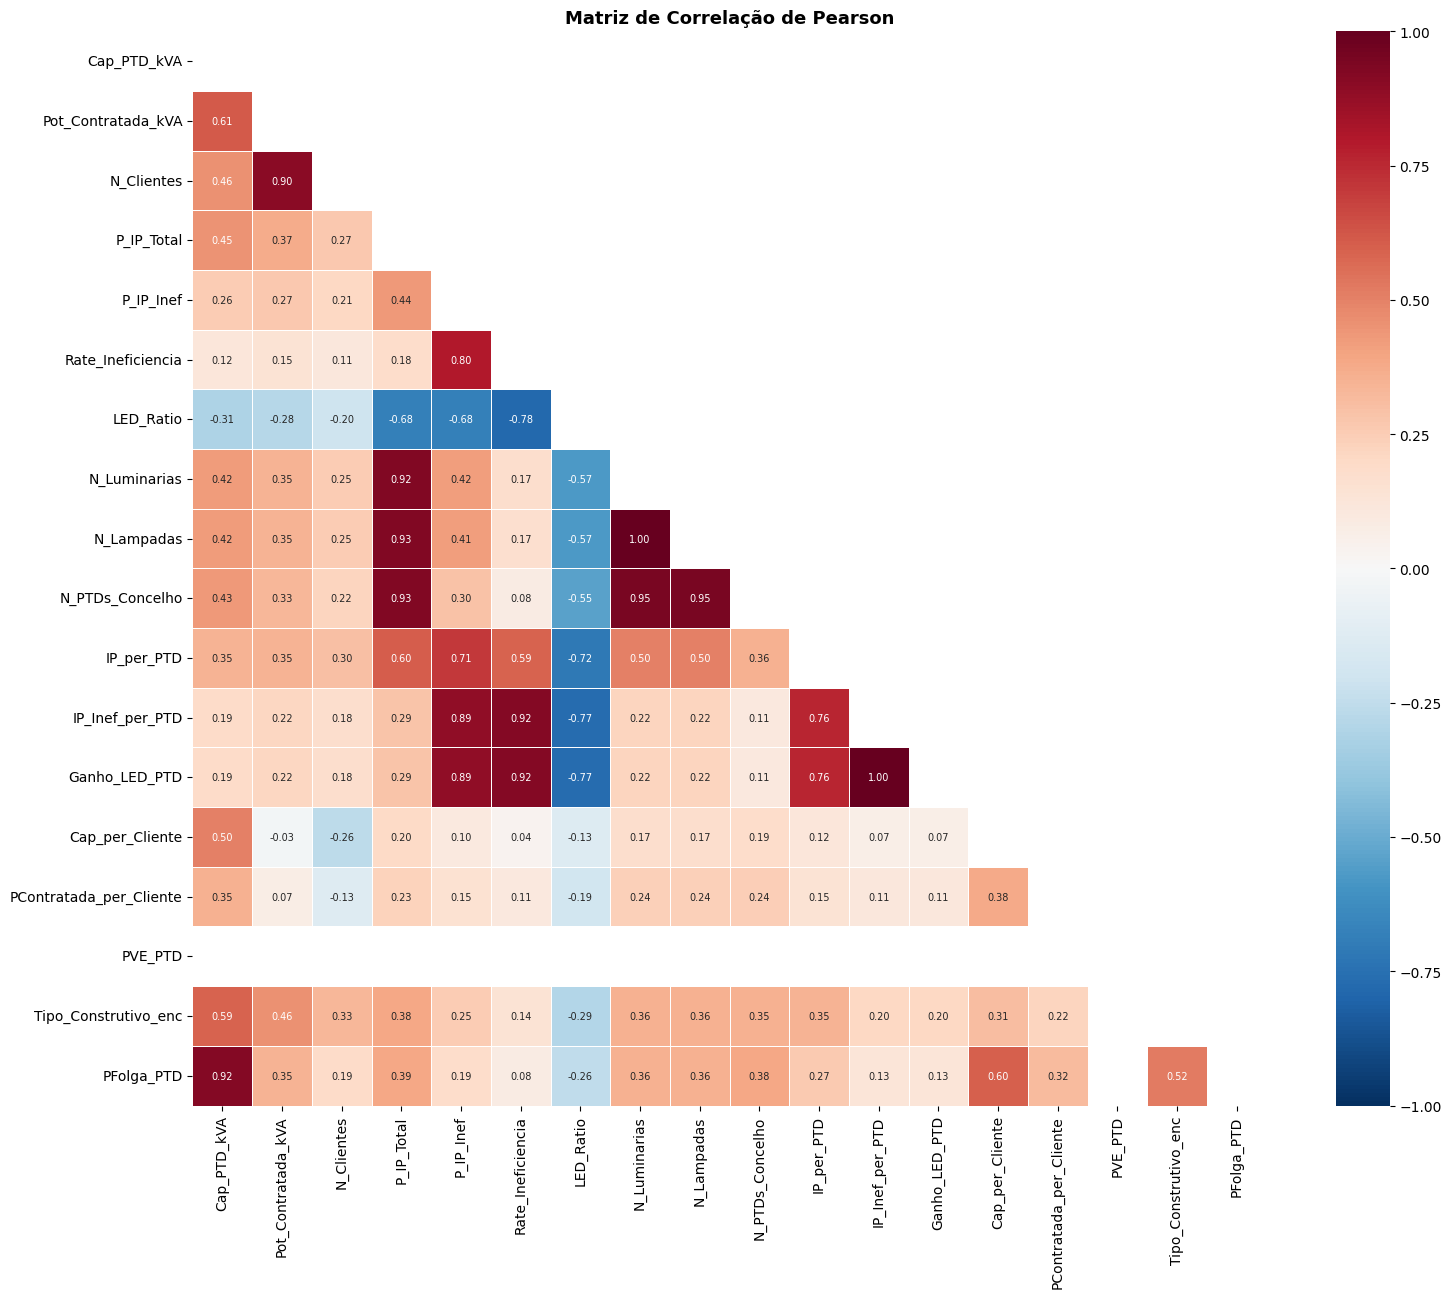

Correlações com PFolga_PTD (ordenadas):
  Cap_PTD_kVA                   : +0.9159
  Cap_per_Cliente               : +0.5996
  Tipo_Construtivo_enc          : +0.5198
  P_IP_Total                    : +0.3884
  N_PTDs_Concelho               : +0.3840
  N_Lampadas                    : +0.3585
  N_Luminarias                  : +0.3575
  Pot_Contratada_kVA            : +0.3470
  PContratada_per_Cliente       : +0.3165
  IP_per_PTD                    : +0.2655
  LED_Ratio                     : -0.2573
  N_Clientes                    : +0.1880
  P_IP_Inef                     : +0.1874
  IP_Inef_per_PTD               : +0.1295
  Ganho_LED_PTD                 : +0.1295
  Rate_Ineficiencia             : +0.0786
  PVE_PTD                       : +nan


In [9]:
corr_matrix = df_clean[FEATURES + ['PFolga_PTD']].corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlações com PFolga_PTD (ordenadas):')
corr_target = corr_matrix['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:30s}: {val:+.4f}')

### 4.2.2 - Regressão Linear Simples (k-fold CV)

In [10]:
# Selecionar variável com maior correlação absoluta com PFolga_PTD
# PVE_PTD tem valor constante (13.2) - excluir da seleção
corr_safe = corr_matrix['PFolga_PTD'].drop('PFolga_PTD')
corr_safe = corr_safe[corr_safe.index != 'PVE_PTD']
best_feat = corr_safe.abs().idxmax()
best_feat_idx = FEATURES.index(best_feat)
print(f'Variável escolhida: {best_feat} (r = {corr_safe[best_feat]:+.4f})')
print(f'Justificação: maior correlação absoluta com PFolga_PTD')

X_simple = X[:, best_feat_idx].reshape(-1, 1)
kf10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_s, rmse_s = [], []
for tr, te in kf10.split(X_simple):
    m = LinearRegression()
    m.fit(X_simple[tr], y_reg[tr])
    p = m.predict(X_simple[te])
    mae_s.append(mean_absolute_error(y_reg[te], p))
    rmse_s.append(np.sqrt(mean_squared_error(y_reg[te], p)))

lr_simple = LinearRegression().fit(X_simple, y_reg)

print(f'\na) Função linear:')
print(f'   PFolga_PTD = {lr_simple.coef_[0]:.6f} * {best_feat} + ({lr_simple.intercept_:.4f})')
print(f'\nc) Métricas (10-fold CV):')
print(f'   MAE:  {np.mean(mae_s):.4f} ± {np.std(mae_s):.4f} kVA')
print(f'   RMSE: {np.mean(rmse_s):.4f} ± {np.std(rmse_s):.4f} kVA')

Variável escolhida: Cap_PTD_kVA (r = +0.9159)
Justificação: maior correlação absoluta com PFolga_PTD

a) Função linear:
   PFolga_PTD = 0.593748 * Cap_PTD_kVA + (-32.1888)

c) Métricas (10-fold CV):
   MAE:  50.7496 ± 0.3797 kVA
   RMSE: 74.9728 ± 0.6679 kVA


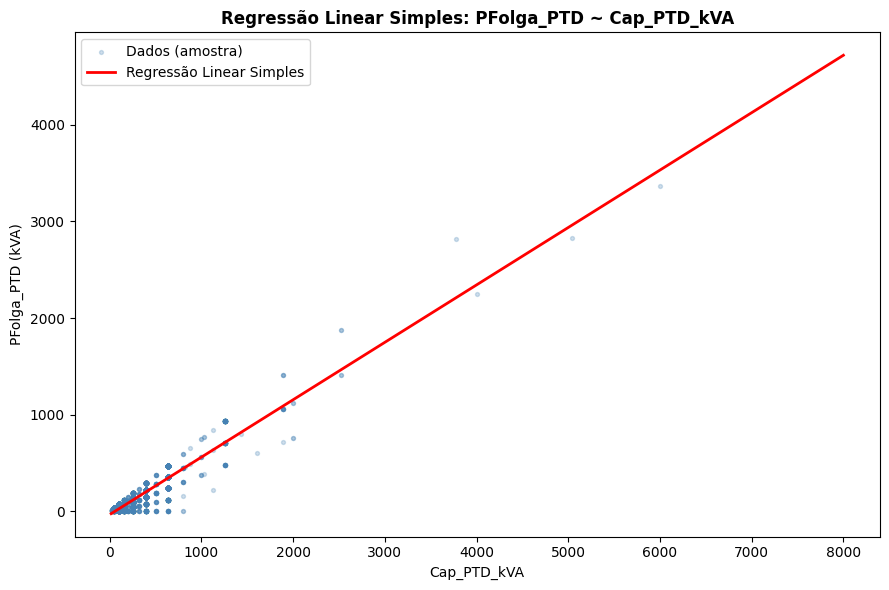

In [11]:
# b) Diagrama de dispersão + reta
rng = np.random.default_rng(SEED)
idx_s = rng.choice(len(X_simple), size=min(4000, len(X_simple)), replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple[idx_s], y_reg[idx_s], alpha=0.25, s=8, color='steelblue', label='Dados (amostra)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, lr_simple.predict(x_line), 'r-', lw=2, label='Regressão Linear Simples')
ax.set_xlabel(best_feat)
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title(f'Regressão Linear Simples: PFolga_PTD ~ {best_feat}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reg_simples.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2.3 - Modelos múltiplos com k-fold CV

In [12]:
def eval_reg(model, X_data, y_data, kf):
    mae_l, rmse_l = [], []
    for tr, te in kf.split(X_data):
        model.fit(X_data[tr], y_data[tr])
        p = model.predict(X_data[te])
        mae_l.append(mean_absolute_error(y_data[te], p))
        rmse_l.append(np.sqrt(mean_squared_error(y_data[te], p)))
    return {'MAE_mean': np.mean(mae_l), 'MAE_std': np.std(mae_l),
            'RMSE_mean': np.mean(rmse_l), 'RMSE_std': np.std(rmse_l),
            'MAE_folds': mae_l}

print('Funções definidas.')

Funções definidas.


In [13]:
# a) Regressão Linear Múltipla
lr_multi = LinearRegression()
res_lr = eval_reg(lr_multi, X_scaled, y_reg, kf10)
lr_multi.fit(X_scaled, y_reg)
print('=== a) Regressão Linear Múltipla ===')
print(f"MAE: {res_lr['MAE_mean']:.4f} ± {res_lr['MAE_std']:.4f} | RMSE: {res_lr['RMSE_mean']:.4f}")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coef': lr_multi.coef_})\
           .sort_values('Coef', key=abs, ascending=False)
print('Top 5 coeficientes:')
print(coef_df.head(5).to_string(index=False))

=== a) Regressão Linear Múltipla ===
MAE: 33.8709 ± 0.4171 | RMSE: 52.4938
Top 5 coeficientes:
           Feature        Coef
       Cap_PTD_kVA  208.986714
        N_Lampadas -151.747858
      N_Luminarias  137.767964
Pot_Contratada_kVA  -37.596344
        N_Clientes  -28.089963


In [14]:
# b) Árvore de Regressão – otimizar max_depth
print('=== b) Árvore de Regressão – Otimização ===')
depth_res = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_reg(DecisionTreeRegressor(max_depth=d, random_state=SEED), X, y_reg, kf10)
    depth_res[d] = r
    print(f'  depth={str(d):4}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')

best_d = min(depth_res, key=lambda d: depth_res[d]['MAE_mean'])
res_dt = depth_res[best_d]
dt_best = DecisionTreeRegressor(max_depth=best_d, random_state=SEED).fit(X, y_reg)
print(f'-> Melhor depth: {best_d} | MAE: {res_dt["MAE_mean"]:.4f} | RMSE: {res_dt["RMSE_mean"]:.4f}')

=== b) Árvore de Regressão – Otimização ===
  depth=3   : MAE=45.4161 ± 0.8430
  depth=5   : MAE=36.0469 ± 0.5934
  depth=7   : MAE=33.0371 ± 0.4267
  depth=10  : MAE=32.4073 ± 0.3924
  depth=15  : MAE=34.5547 ± 0.4773
  depth=None: MAE=37.5416 ± 0.3847
-> Melhor depth: 10 | MAE: 32.4073 | RMSE: 54.9940


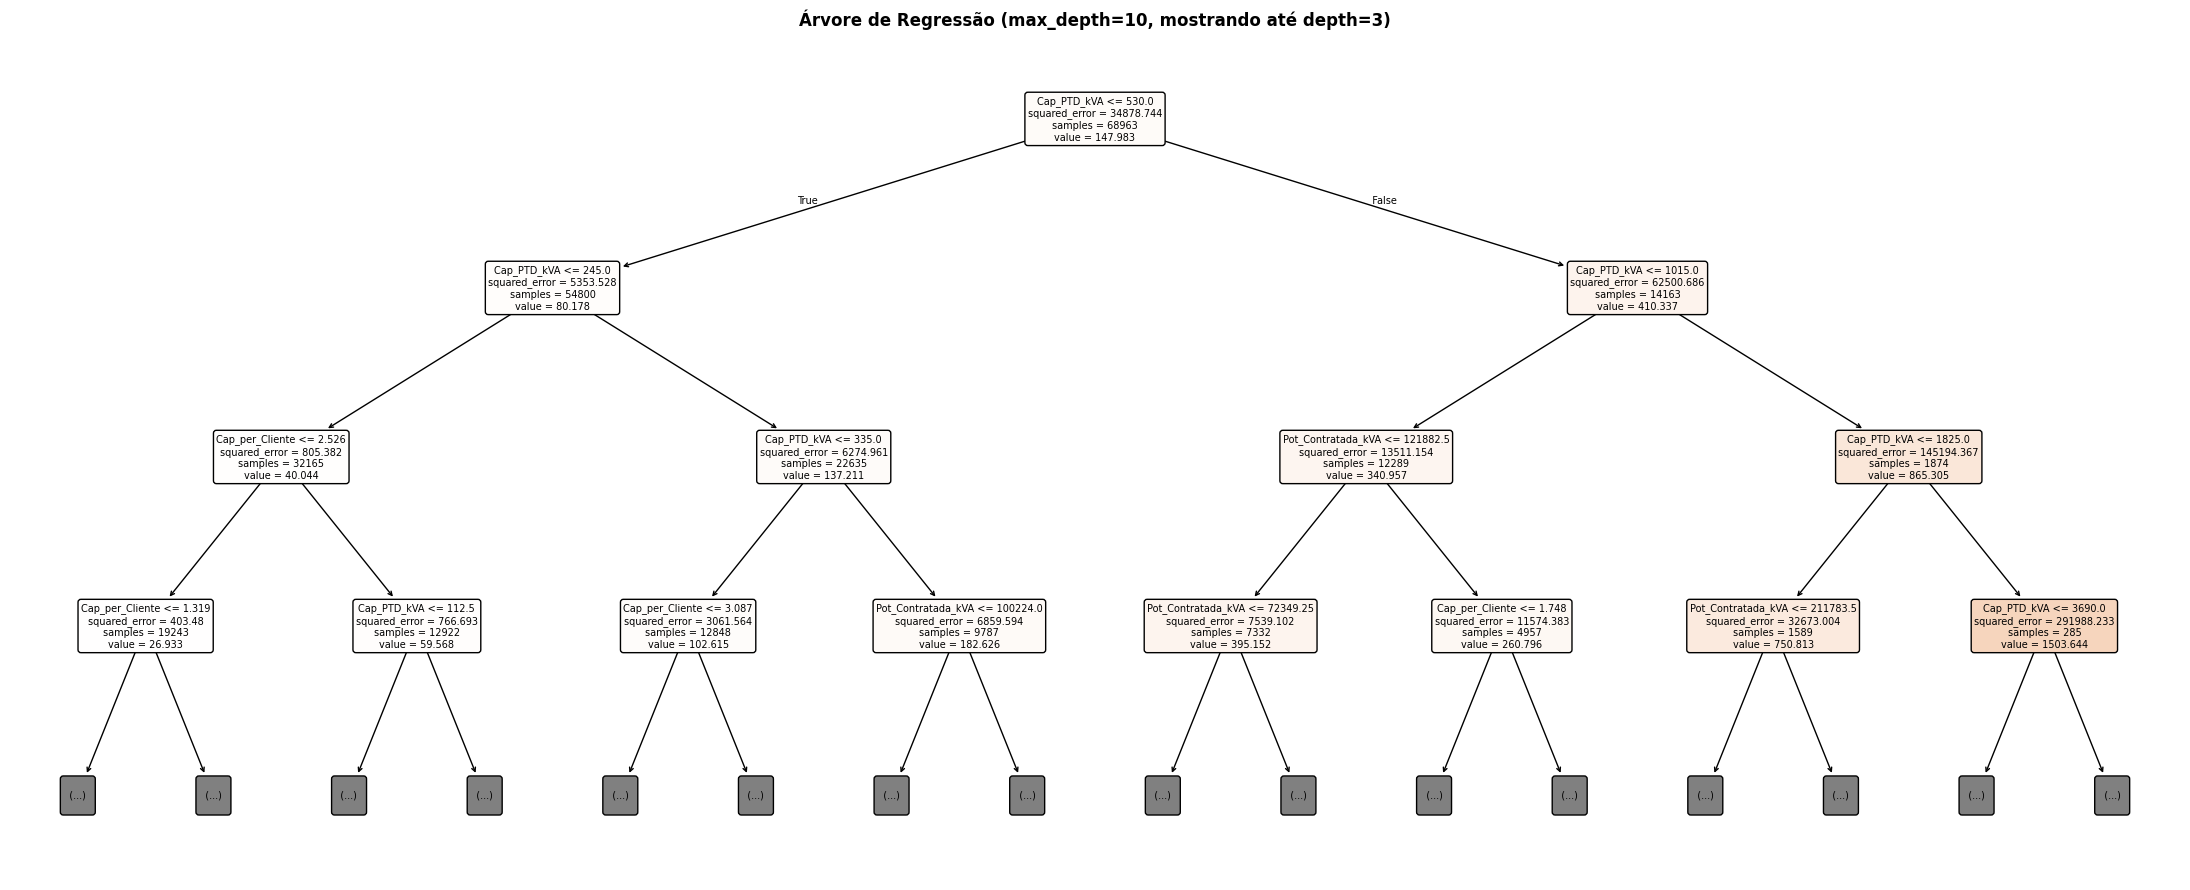

In [15]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_best, max_depth=3, feature_names=FEATURES,
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Regressão (max_depth={best_d}, mostrando até depth=3)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# c) SVM – otimização do kernel (subsample por limitações computacionais)
print('=== c) SVM – Otimização de Kernel (subsample n=6000) ===')
rng = np.random.default_rng(SEED)
idx_sv = rng.choice(len(X_scaled), 6000, replace=False)
svm_kr = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_reg(SVR(kernel=k, C=1.0), X_scaled[idx_sv], y_reg[idx_sv], kf10)
    svm_kr[k] = r
    print(f'  kernel={k:6}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')
best_k_svm = min(svm_kr, key=lambda k: svm_kr[k]['MAE_mean'])
res_svm = svm_kr[best_k_svm]
print(f'-> Melhor kernel: {best_k_svm}')

=== c) SVM – Otimização de Kernel (subsample n=6000) ===
  kernel=linear: MAE=33.3818 ± 1.1589
  kernel=rbf   : MAE=68.4200 ± 4.6009
  kernel=poly  : MAE=78.2496 ± 4.1089
-> Melhor kernel: linear


In [17]:
# d) Rede Neuronal – 3 configurações estruturadas
print('=== d) Rede Neuronal – 3 Configurações ===')
X_tr_n, X_vl_n, y_tr_n, y_vl_n = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=SEED)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

# (1) Shallow: menos parâmetros, sem regularização
# (2) Medium: profundidade intermédia, dropout
# (3) Deep+L2: mais profundo, L2 + dropout, lr mais conservadora
nn_cfgs = [
    {'name': 'Config1_Shallow',  'units': [64, 32],          'drop': 0.0, 'l2': 0.0,   'lr': 1e-3},
    {'name': 'Config2_Medium',   'units': [128, 64, 32],      'drop': 0.2, 'l2': 0.0,   'lr': 1e-3},
    {'name': 'Config3_Deep_L2',  'units': [256, 128, 64, 32], 'drop': 0.3, 'l2': 1e-4,  'lr': 5e-4},
]
hist_nn, nn_res = {}, {}
for cfg in nn_cfgs:
    tf.random.set_seed(SEED)
    inp = keras.Input(shape=(X_scaled.shape[1],))
    x = inp
    for u in cfg['units']:
        x = layers.Dense(u, activation='relu',
                          kernel_regularizer=regularizers.l2(cfg['l2']) if cfg['l2'] else None)(x)
        if cfg['drop']: x = layers.Dropout(cfg['drop'])(x)
    m = keras.Model(inp, layers.Dense(1)(x))
    m.compile(optimizer=keras.optimizers.Adam(cfg['lr']), loss='mse', metrics=['mae'])
    h = m.fit(X_tr_n, y_tr_n, validation_data=(X_vl_n, y_vl_n),
              epochs=150, batch_size=256, callbacks=[es], verbose=0)
    hist_nn[cfg['name']] = h.history
    p = m.predict(X_vl_n, verbose=0).flatten()
    nn_res[cfg['name']] = {
        'MAE_mean': mean_absolute_error(y_vl_n, p),
        'RMSE_mean': np.sqrt(mean_squared_error(y_vl_n, p)),
        'epochs': len(h.history['loss'])
    }
    r = nn_res[cfg['name']]
    print(f"  {cfg['name']:25}: MAE={r['MAE_mean']:.4f} | RMSE={r['RMSE_mean']:.4f} | epochs={r['epochs']}")
best_nn = min(nn_res, key=lambda k: nn_res[k]['MAE_mean'])
print(f'-> Melhor NN: {best_nn}')

=== d) Rede Neuronal – 3 Configurações ===
  Config1_Shallow          : MAE=31.2109 | RMSE=49.7025 | epochs=150
  Config2_Medium           : MAE=54.9919 | RMSE=87.0285 | epochs=10
  Config3_Deep_L2          : MAE=53.5144 | RMSE=84.7626 | epochs=10
-> Melhor NN: Config1_Shallow


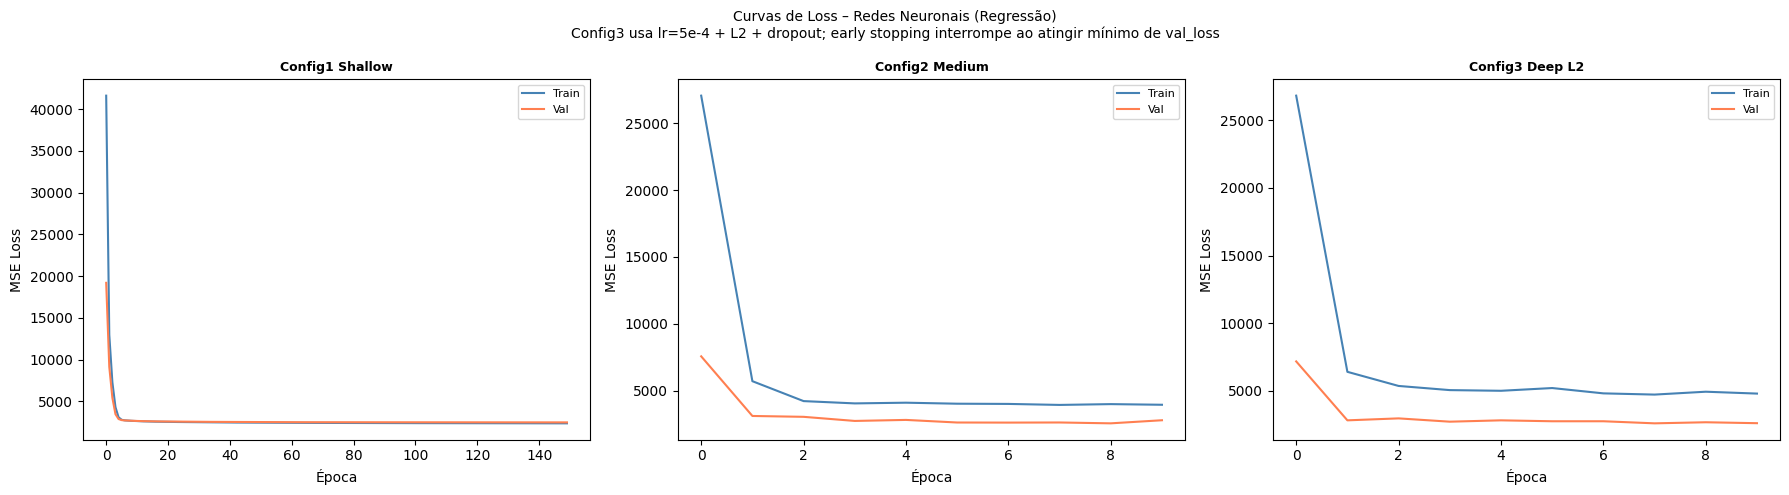

In [18]:
# (2) Curvas de loss + (3) discussão learning rate e early stopping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cfgs):
    h = hist_nn[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – Redes Neuronais (Regressão)\n'
             'Config3 usa lr=5e-4 + L2 + dropout; early stopping interrompe ao atingir mínimo de val_loss', fontsize=10)
plt.tight_layout()
plt.savefig('fig_nn_loss_reg.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2.4 - Comparação e variáveis mais relevantes

=== Comparação de Modelos de Regressão (ordenado por MAE) ===
              Modelo       MAE  MAE_std      RMSE
NN (Config1_Shallow) 31.210868 0.000000 49.702546
       Árvore (d=10) 32.407348 0.392382 54.993983
        SVM (linear) 33.381815 1.158905 53.735937
Reg. Linear Múltipla 33.870854 0.417125 52.493822
 Reg. Linear Simples 50.749592 0.379726 74.972821


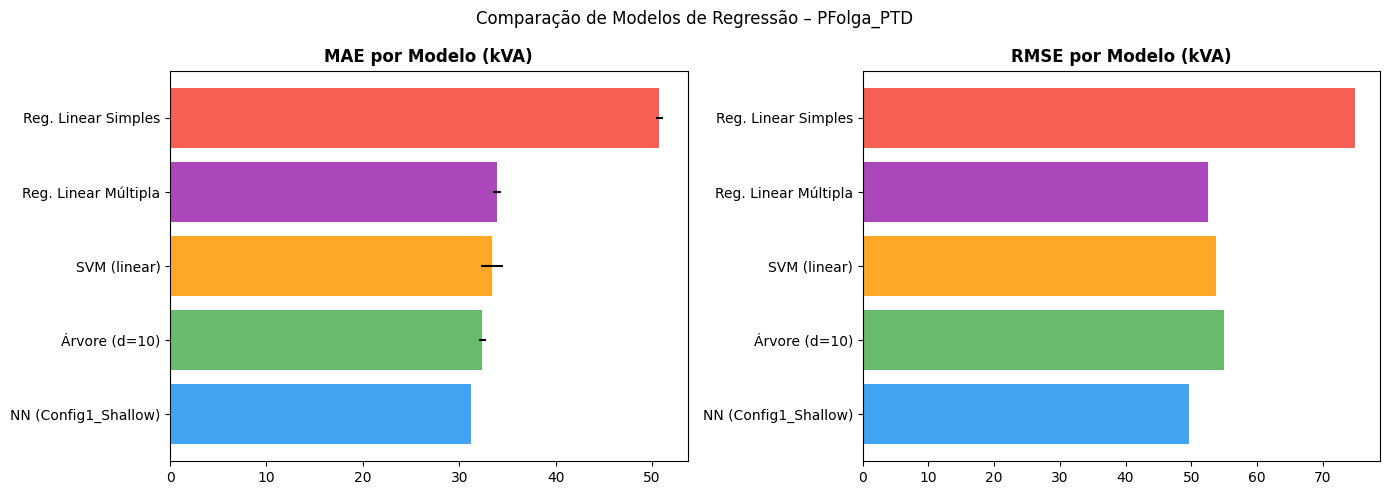

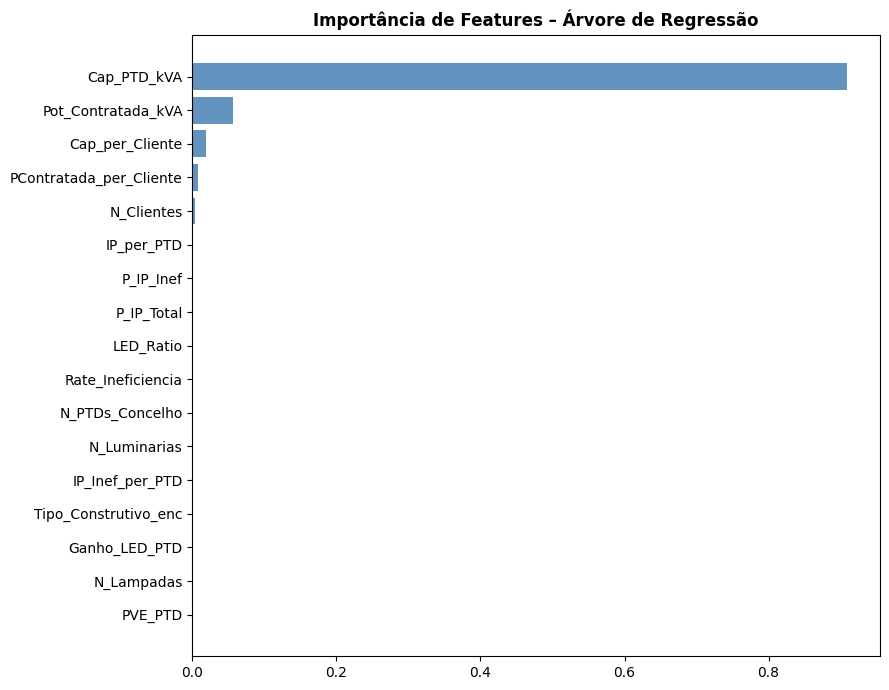

In [19]:
r_nn = nn_res[best_nn]
results_reg = pd.DataFrame([
    {'Modelo': 'Reg. Linear Simples',  'MAE': np.mean(mae_s),     'MAE_std': np.std(mae_s),    'RMSE': np.mean(rmse_s)},
    {'Modelo': 'Reg. Linear Múltipla', 'MAE': res_lr['MAE_mean'],  'MAE_std': res_lr['MAE_std'], 'RMSE': res_lr['RMSE_mean']},
    {'Modelo': f'Árvore (d={best_d})', 'MAE': res_dt['MAE_mean'],  'MAE_std': res_dt['MAE_std'], 'RMSE': res_dt['RMSE_mean']},
    {'Modelo': f'SVM ({best_k_svm})',  'MAE': res_svm['MAE_mean'], 'MAE_std': res_svm['MAE_std'],'RMSE': res_svm['RMSE_mean']},
    {'Modelo': f'NN ({best_nn})',      'MAE': r_nn['MAE_mean'],    'MAE_std': 0,                 'RMSE': r_nn['RMSE_mean']},
]).sort_values('MAE').reset_index(drop=True)

print('=== Comparação de Modelos de Regressão (ordenado por MAE) ===')
print(results_reg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
axes[0].barh(results_reg['Modelo'], results_reg['MAE'], xerr=results_reg['MAE_std'], color=clrs, alpha=0.85)
axes[0].set_title('MAE por Modelo (kVA)', fontweight='bold')
axes[1].barh(results_reg['Modelo'], results_reg['RMSE'], color=clrs, alpha=0.85)
axes[1].set_title('RMSE por Modelo (kVA)', fontweight='bold')
plt.suptitle('Comparação de Modelos de Regressão – PFolga_PTD', fontsize=12)
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

# Importância de variáveis
fi = pd.DataFrame({'Feature': FEATURES, 'Importance': dt_best.feature_importances_})\
      .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi['Feature'], fi['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Regressão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_reg.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2.5 - Curvas de Aprendizagem

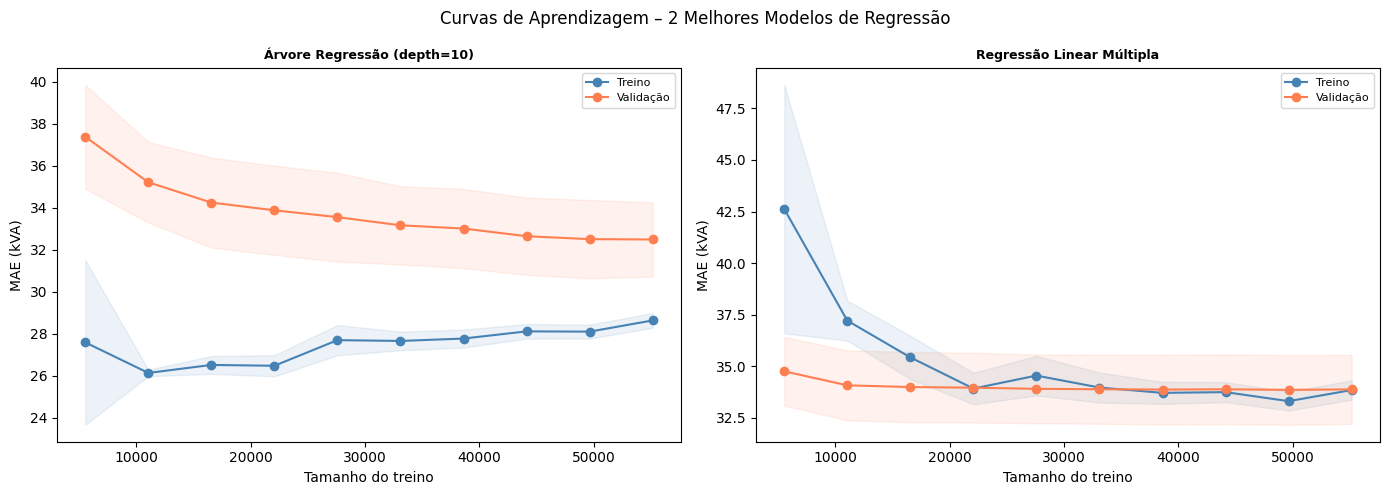

Treino e validação convergentes -> eficiente | val >> treino -> overfitting | ambas altas -> underfitting


In [20]:
def plot_lc(model, Xd, yd, title, ax, scoring='neg_mean_absolute_error'):
    ts, tsc, vsc = learning_curve(model, Xd, yd,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring=scoring, n_jobs=-1)
    tm, vm = -tsc.mean(1), -vsc.mean(1)
    ts_std, vs_std = tsc.std(1), vsc.std(1)
    ax.plot(ts, tm, 'o-', color='steelblue', label='Treino')
    ax.plot(ts, vm, 'o-', color='coral', label='Validação')
    ax.fill_between(ts, tm-ts_std, tm+ts_std, alpha=0.1, color='steelblue')
    ax.fill_between(ts, vm-vs_std, vm+vs_std, alpha=0.1, color='coral')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel('MAE (kVA)')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(DecisionTreeRegressor(max_depth=best_d, random_state=SEED), X, y_reg,
        f'Árvore Regressão (depth={best_d})', axes[0])
plot_lc(LinearRegression(), X_scaled, y_reg, 'Regressão Linear Múltipla', axes[1])
plt.suptitle('Curvas de Aprendizagem – 2 Melhores Modelos de Regressão', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Treino e validação convergentes -> eficiente | val >> treino -> overfitting | ambas altas -> underfitting')

### 4.2.6 - Testes Estatísticos (α = 5%)

In [21]:
# Metodologia: Shapiro-Wilk nas diferenças -> decide paramétrico vs não-paramétrico
# (consistente com TP1 onde a mesma lógica foi aplicada)
mae1 = np.array(res_dt['MAE_folds'])
mae2 = np.array(res_lr['MAE_folds'])
diffs = mae1 - mae2

_, p_sw = shapiro(diffs)
print(f'Shapiro-Wilk (diferenças MAE): p={p_sw:.4f}')
if p_sw > 0.05:
    stat, p = ttest_rel(mae1, mae2)
    tnm = 't-test pareado'
else:
    stat, p = wilcoxon(mae1, mae2)
    tnm = 'Wilcoxon signed-rank'

print(f'{tnm}: stat={stat:.4f}, p={p:.4f}')
if p < 0.05:
    winner = f'Árvore (d={best_d})' if mae1.mean() < mae2.mean() else 'Reg. Linear Múltipla'
    print(f'-> Diferença significativa (p<0.05). Melhor: {winner}')
else:
    print('-> Sem diferença significativa (p>=0.05).')

Shapiro-Wilk (diferenças MAE): p=0.5864
t-test pareado: stat=-16.9547, p=0.0000
-> Diferença significativa (p<0.05). Melhor: Árvore (d=10)


---
## 4.3. Classificação - Previsão de utilizRede
### 4.3.0 - Criar variável utilizRede

Fronteiras: baixo <= 0.3900 < medio <= 0.5900 < alto

Distribuição:
utilizRede
baixo    35230
medio    17175
alto     16558
Name: count, dtype: int64


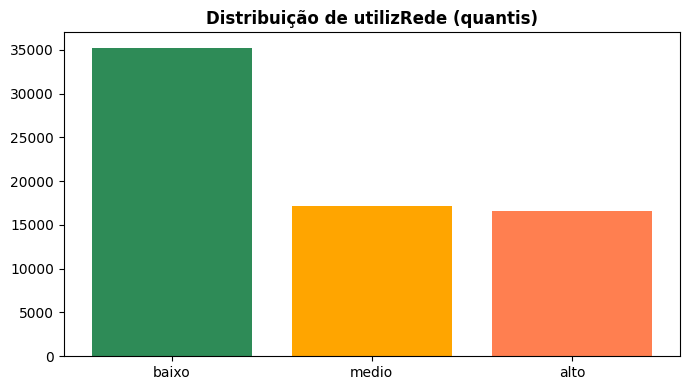

In [22]:
# Discretização de Util_Decimal em 3 classes por quantis (terços)
# Justificação: quantis garantem classes equilibradas independentemente da distribuição
# No TP1, observou-se concentração de PTDs na faixa 60-79% (Util_Decimal ~0.79)
# pelo que intervalos fixos criariam classes muito desbalanceadas
q33 = df_clean['Util_Decimal'].quantile(1/3)
q66 = df_clean['Util_Decimal'].quantile(2/3)
print(f'Fronteiras: baixo <= {q33:.4f} < medio <= {q66:.4f} < alto')

df_clean = df_clean.copy()
df_clean['utilizRede'] = pd.cut(
    df_clean['Util_Decimal'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['baixo', 'medio', 'alto']
)
print('\nDistribuição:')
print(df_clean['utilizRede'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
c = df_clean['utilizRede'].value_counts().sort_index()
ax.bar(c.index, c.values, color=['seagreen','orange','coral'])
ax.set_title('Distribuição de utilizRede (quantis)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_utilizRede.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Features de classificação: excluir Util_Decimal (leakage direto)
FEATURES_CLF = [f for f in FEATURES if f != 'Util_Decimal']
X_clf = df_clean[FEATURES_CLF].values
y_clf = df_clean['utilizRede'].astype(str).values
X_clf_sc = StandardScaler().fit_transform(X_clf)
kf10c = KFold(n_splits=10, shuffle=True, random_state=SEED)
print(f'Features CLF ({len(FEATURES_CLF)}): shape={X_clf.shape}')

Features CLF (17): shape=(68963, 17)


### 4.3.1 - Modelos de Classificação

In [24]:
def eval_clf(model, Xd, yd, kf):
    a,p,r,f = [],[],[],[]
    for tr, te in kf.split(Xd):
        model.fit(Xd[tr], yd[tr])
        yp = model.predict(Xd[te])
        a.append(accuracy_score(yd[te], yp))
        p.append(precision_score(yd[te], yp, average='weighted', zero_division=0))
        r.append(recall_score(yd[te], yp, average='weighted', zero_division=0))
        f.append(f1_score(yd[te], yp, average='weighted', zero_division=0))
    return {'Acc':(np.mean(a),np.std(a)), 'Prec':(np.mean(p),np.std(p)),
            'Rec':(np.mean(r),np.std(r)), 'F1':(np.mean(f),np.std(f)), 'Acc_folds':a}

print('Função de avaliação definida.')

Função de avaliação definida.


In [25]:
# a) Árvore de Decisão
print('=== a) Árvore de Decisão ===')
dcr = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_clf(DecisionTreeClassifier(max_depth=d, random_state=SEED), X_clf, y_clf, kf10c)
    dcr[d] = r
    print(f'  depth={str(d):4}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_dc = max(dcr, key=lambda d: dcr[d]['Acc'][0])
res_dtc = dcr[best_dc]
dt_clf = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED).fit(X_clf, y_clf)
print(f'-> Melhor depth: {best_dc} | Acc: {res_dtc["Acc"][0]:.4f}')

=== a) Árvore de Decisão ===
  depth=3   : Acc=0.6598 ± 0.0044 | F1=0.6544
  depth=5   : Acc=0.6898 ± 0.0032 | F1=0.6771
  depth=7   : Acc=0.6992 ± 0.0041 | F1=0.6912
  depth=10  : Acc=0.6962 ± 0.0042 | F1=0.6878
  depth=15  : Acc=0.6666 ± 0.0037 | F1=0.6591
  depth=None: Acc=0.6327 ± 0.0072 | F1=0.6264
-> Melhor depth: 7 | Acc: 0.6992


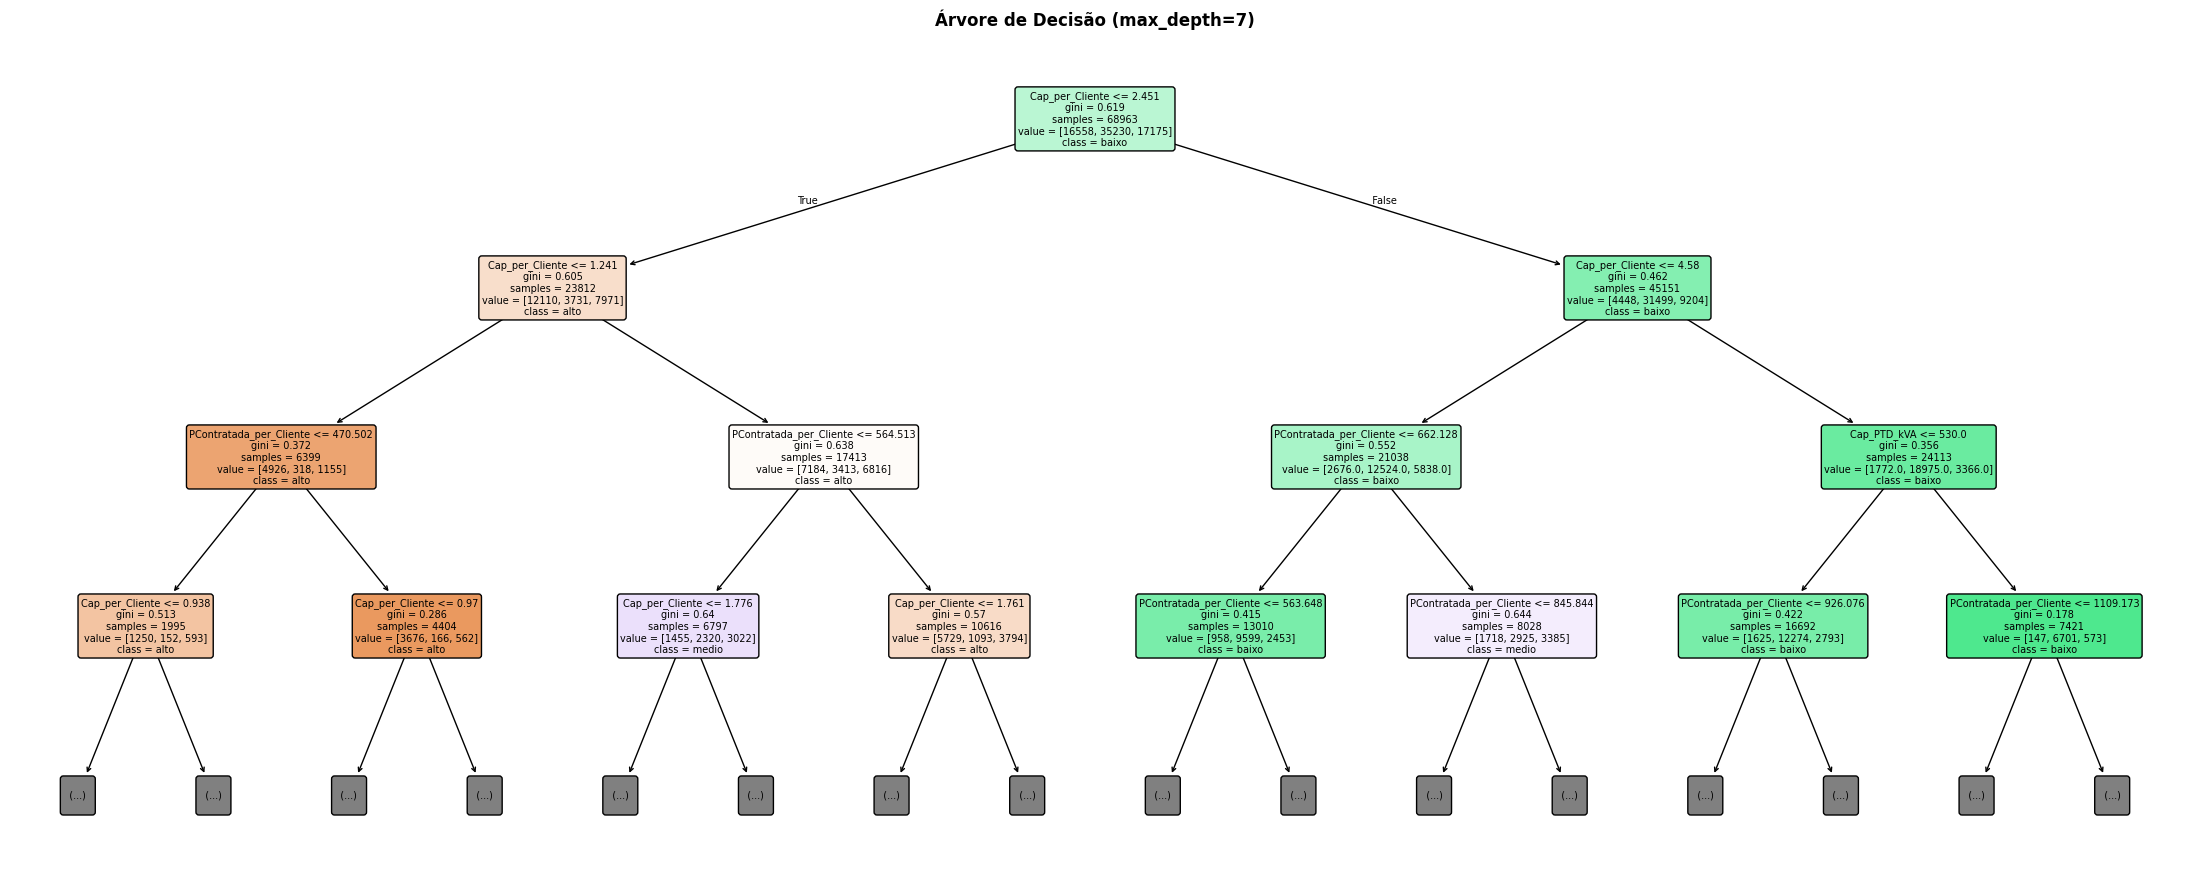

In [26]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_clf, max_depth=3, feature_names=FEATURES_CLF,
          class_names=dt_clf.classes_, filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Decisão (max_depth={best_dc})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# b) Rede Neuronal Classificação – 3 configurações
print('=== b) Rede Neuronal Classificação ===')
le_c = LabelEncoder()
y_enc = le_c.fit_transform(y_clf)
y_cat = to_categorical(y_enc, 3)
Xt, Xv, yt, yv = train_test_split(X_clf_sc, y_cat, test_size=0.2, random_state=SEED)
es_c = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

# (1) Shallow: arquitetura simples
# (2) Medium: profundidade intermédia com dropout
# (3) Deep: mais camadas, lr conservadora
nn_cc = [
    {'name': 'Config1_Shallow', 'units': [64, 32],          'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config2_Medium',  'units': [128, 64, 32],      'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config3_Deep',    'units': [256, 128, 64, 32], 'drop': 0.3, 'lr': 5e-4},
]
hist_clf, nn_cr = {}, {}
for cfg in nn_cc:
    tf.random.set_seed(SEED)
    inp = keras.Input(shape=(X_clf_sc.shape[1],))
    x = inp
    for u in cfg['units']:
        x = layers.Dense(u, activation='relu')(x)
        x = layers.Dropout(cfg['drop'])(x)
    mc = keras.Model(inp, layers.Dense(3, activation='softmax')(x))
    mc.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
               loss='categorical_crossentropy', metrics=['accuracy'])
    hc = mc.fit(Xt, yt, validation_data=(Xv, yv),
                epochs=150, batch_size=256, callbacks=[es_c], verbose=0)
    hist_clf[cfg['name']] = hc.history
    ypc = np.argmax(mc.predict(Xv, verbose=0), 1)
    ytc = np.argmax(yv, 1)
    nn_cr[cfg['name']] = {
        'Acc': (accuracy_score(ytc, ypc), 0),
        'F1': (f1_score(ytc, ypc, average='weighted'), 0),
        'Acc_folds': [accuracy_score(ytc, ypc)],
        'epochs': len(hc.history['loss'])
    }
    r = nn_cr[cfg['name']]
    print(f"  {cfg['name']:22}: Acc={r['Acc'][0]:.4f} | F1={r['F1'][0]:.4f} | epochs={r['epochs']}")
best_nnc = max(nn_cr, key=lambda k: nn_cr[k]['Acc'][0])
print(f'-> Melhor NN: {best_nnc}')

=== b) Rede Neuronal Classificação ===
  Config1_Shallow       : Acc=0.7128 | F1=0.7009 | epochs=79
  Config2_Medium        : Acc=0.6819 | F1=0.6367 | epochs=10
  Config3_Deep          : Acc=0.6729 | F1=0.6168 | epochs=10
-> Melhor NN: Config1_Shallow


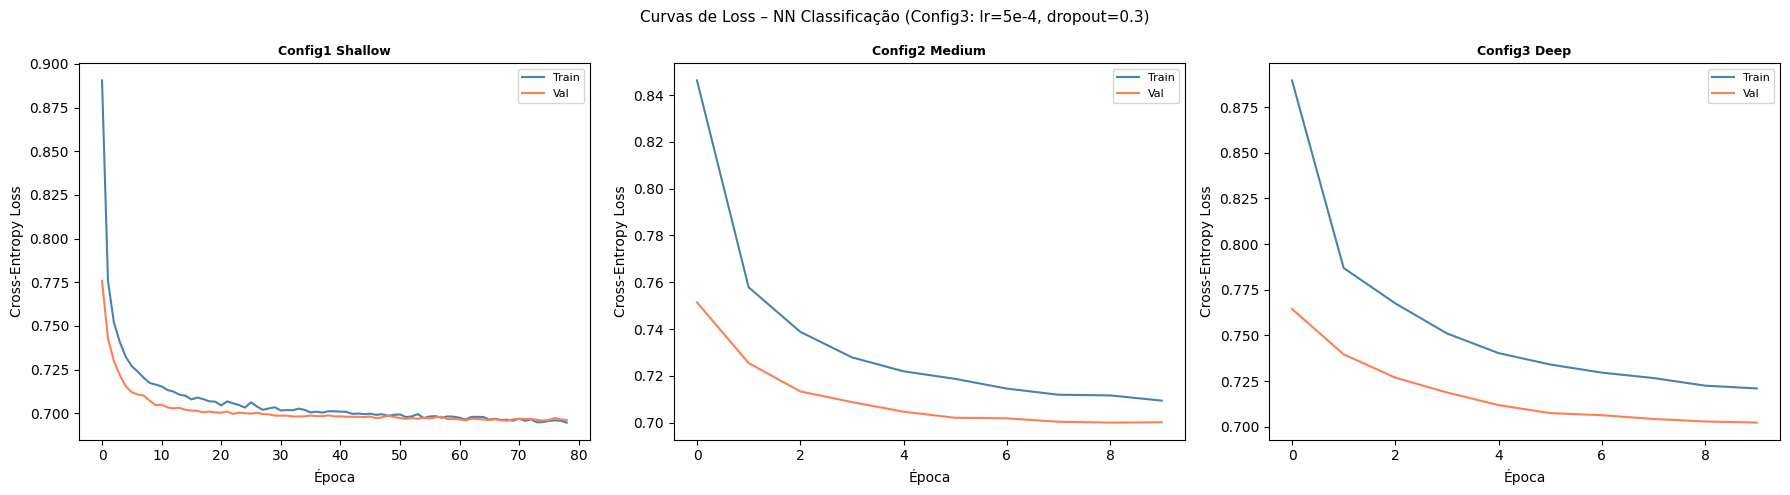

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cc):
    h = hist_clf[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Cross-Entropy Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – NN Classificação (Config3: lr=5e-4, dropout=0.3)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_nn_loss_clf.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# c) SVM
print('=== c) SVM Classificação (subsample n=6000) ===')
rng = np.random.default_rng(SEED)
isc = rng.choice(len(X_clf_sc), 6000, replace=False)
svc_r = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_clf(SVC(kernel=k, C=1.0, random_state=SEED), X_clf_sc[isc], y_clf[isc], kf10c)
    svc_r[k] = r
    print(f'  kernel={k:6}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_ks = max(svc_r, key=lambda k: svc_r[k]['Acc'][0])
res_svc = svc_r[best_ks]
print(f'-> Melhor kernel: {best_ks}')

=== c) SVM Classificação (subsample n=6000) ===
  kernel=linear: Acc=0.6715 ± 0.0144 | F1=0.6278
  kernel=rbf   : Acc=0.6842 ± 0.0153 | F1=0.6571
  kernel=poly  : Acc=0.5913 ± 0.0193 | F1=0.5155
-> Melhor kernel: rbf


=== d) KNN – Otimização de K ===
  k= 1: Acc=0.6042 ± 0.0039 | F1=0.6049
  k= 3: Acc=0.6358 ± 0.0040 | F1=0.6300
  k= 5: Acc=0.6544 ± 0.0030 | F1=0.6402
  k= 7: Acc=0.6650 ± 0.0051 | F1=0.6507
  k=10: Acc=0.6706 ± 0.0051 | F1=0.6540
  k=15: Acc=0.6734 ± 0.0064 | F1=0.6573
  k=20: Acc=0.6724 ± 0.0055 | F1=0.6545
-> Melhor K: 15


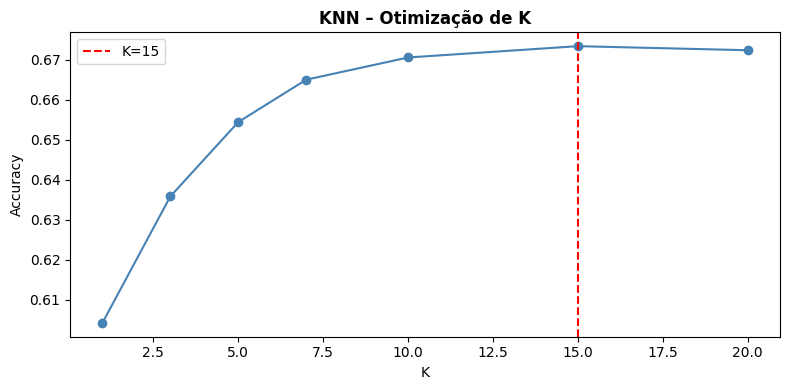

In [30]:
# d) KNN
print('=== d) KNN – Otimização de K ===')
knn_r = {}
for k in [1, 3, 5, 7, 10, 15, 20]:
    r = eval_clf(KNeighborsClassifier(n_neighbors=k), X_clf_sc, y_clf, kf10c)
    knn_r[k] = r
    print(f'  k={k:2}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_knn = max(knn_r, key=lambda k: knn_r[k]['Acc'][0])
res_knn = knn_r[best_knn]
print(f'-> Melhor K: {best_knn}')

fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_r.keys())
ax.plot(ks, [knn_r[k]['Acc'][0] for k in ks], 'o-', color='steelblue')
ax.axvline(best_knn, color='red', ls='--', label=f'K={best_knn}')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.set_title('KNN – Otimização de K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3.2 – Métricas (média ± desvio padrão)

In [31]:
def fmt(m, s): return f'{m:.4f} ± {s:.4f}'
rnn = nn_cr[best_nnc]
results_clf = pd.DataFrame([
    {'Modelo': f'Árvore (d={best_dc})',   'Accuracy': fmt(*res_dtc['Acc']), 'Precision': fmt(*res_dtc['Prec']), 'Recall': fmt(*res_dtc['Rec']), 'F1': fmt(*res_dtc['F1'])},
    {'Modelo': f'NN ({best_nnc})',         'Accuracy': fmt(*rnn['Acc']),    'Precision': '-', 'Recall': '-',    'F1': fmt(*rnn['F1'])},
    {'Modelo': f'SVM ({best_ks})',         'Accuracy': fmt(*res_svc['Acc']),'Precision': fmt(*res_svc['Prec']),'Recall': fmt(*res_svc['Rec']), 'F1': fmt(*res_svc['F1'])},
    {'Modelo': f'KNN (k={best_knn})',      'Accuracy': fmt(*res_knn['Acc']),'Precision': fmt(*res_knn['Prec']),'Recall': fmt(*res_knn['Rec']), 'F1': fmt(*res_knn['F1'])},
])
print('=== Métricas de Classificação (10-fold CV) ===')
print(results_clf.to_string(index=False))

=== Métricas de Classificação (10-fold CV) ===
              Modelo        Accuracy       Precision          Recall              F1
        Árvore (d=7) 0.6992 ± 0.0041 0.6895 ± 0.0037 0.6992 ± 0.0041 0.6912 ± 0.0044
NN (Config1_Shallow) 0.7128 ± 0.0000               -               - 0.7009 ± 0.0000
           SVM (rbf) 0.6842 ± 0.0153 0.6617 ± 0.0202 0.6842 ± 0.0153 0.6571 ± 0.0168
          KNN (k=15) 0.6734 ± 0.0064 0.6525 ± 0.0069 0.6734 ± 0.0064 0.6573 ± 0.0068


### 4.3.3 - Importância de features e comparação com correlações da 4.1

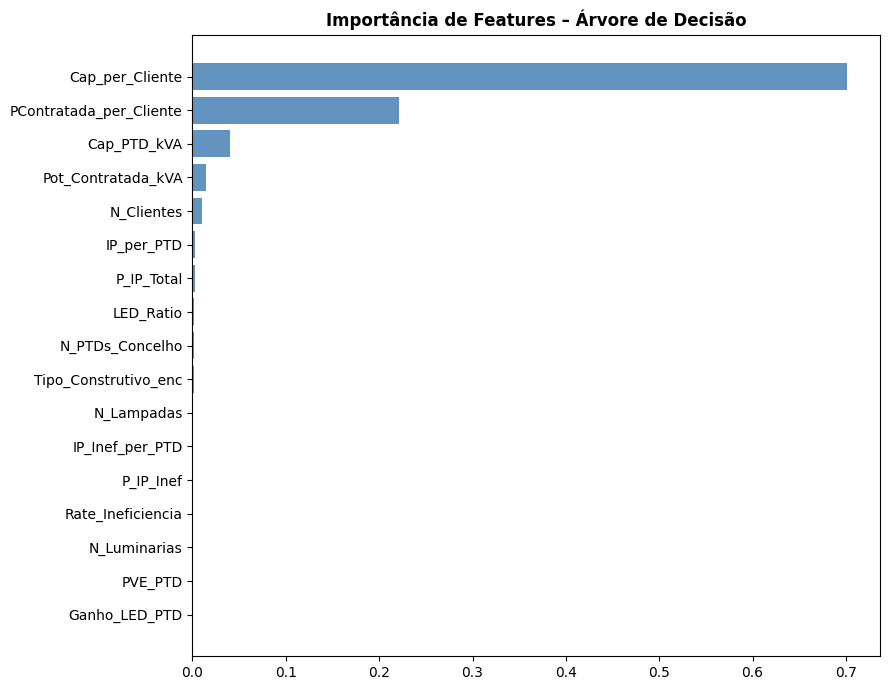

Top 5 features (classificação):
                Feature  Importance
        Cap_per_Cliente    0.701428
PContratada_per_Cliente    0.221384
            Cap_PTD_kVA    0.040126
     Pot_Contratada_kVA    0.014862
             N_Clientes    0.010271

Discussão: comparar com correlações da Secção 4.1.
Features com alta importância na árvore mas baixa correlação de Pearson revelam relações não-lineares.


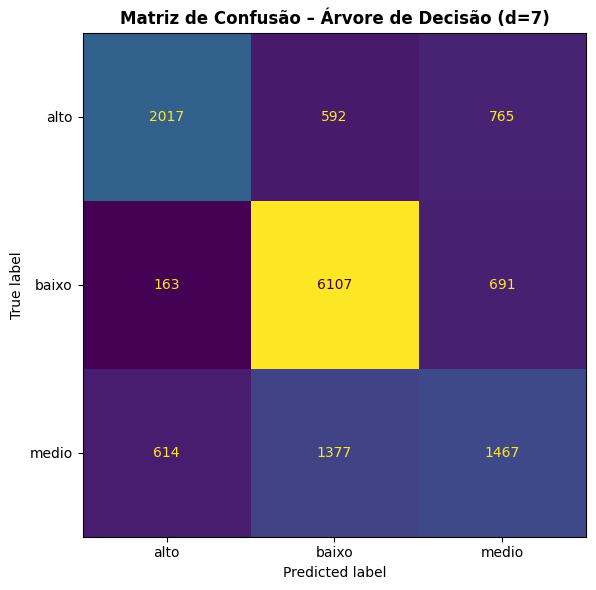

              precision    recall  f1-score   support

        alto       0.72      0.60      0.65      3374
       baixo       0.76      0.88      0.81      6961
       medio       0.50      0.42      0.46      3458

    accuracy                           0.70     13793
   macro avg       0.66      0.63      0.64     13793
weighted avg       0.68      0.70      0.69     13793



In [32]:
fi_clf = pd.DataFrame({'Feature': FEATURES_CLF, 'Importance': dt_clf.feature_importances_})\
          .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_clf['Feature'], fi_clf['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_clf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features (classificação):')
print(fi_clf.tail(5)[['Feature','Importance']].sort_values('Importance', ascending=False).to_string(index=False))
print('\nDiscussão: comparar com correlações da Secção 4.1.')
print('Features com alta importância na árvore mas baixa correlação de Pearson revelam relações não-lineares.')

# Matriz de confusão
Xt2, Xe2, yt2, ye2 = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED)
dt_clf.fit(Xt2, yt2)
yp2 = dt_clf.predict(Xe2)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(ye2, yp2, ax=ax,
    display_labels=np.unique(y_clf), colorbar=False)
ax.set_title(f'Matriz de Confusão – Árvore de Decisão (d={best_dc})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(ye2, yp2))

### 4.3.4 - Teste Estatístico (α = 5%)

In [33]:
# Comparar os 2 melhores modelos (Árvore vs KNN ou SVM conforme resultados)
f1 = np.array(res_dtc['Acc_folds'])
f2 = np.array(res_knn['Acc_folds'])
_, p_sw = shapiro(f1 - f2)
print(f'Shapiro-Wilk (diferenças): p={p_sw:.4f}')
if p_sw > 0.05:
    stat, p = ttest_rel(f1, f2)
    tn = 't-test pareado'
else:
    stat, p = wilcoxon(f1, f2)
    tn = 'Wilcoxon signed-rank'
print(f'{tn}: stat={stat:.4f}, p={p:.4f}')
if p < 0.05:
    w = f'Árvore (d={best_dc})' if f1.mean() > f2.mean() else f'KNN (k={best_knn})'
    print(f'-> Diferença significativa. Melhor: {w}')
else:
    print('-> Sem diferença significativa (p>=0.05).')

Shapiro-Wilk (diferenças): p=0.1110
t-test pareado: stat=16.7147, p=0.0000
-> Diferença significativa. Melhor: Árvore (d=7)


### 4.3.5 - Curvas de Aprendizagem (melhor e pior modelo)

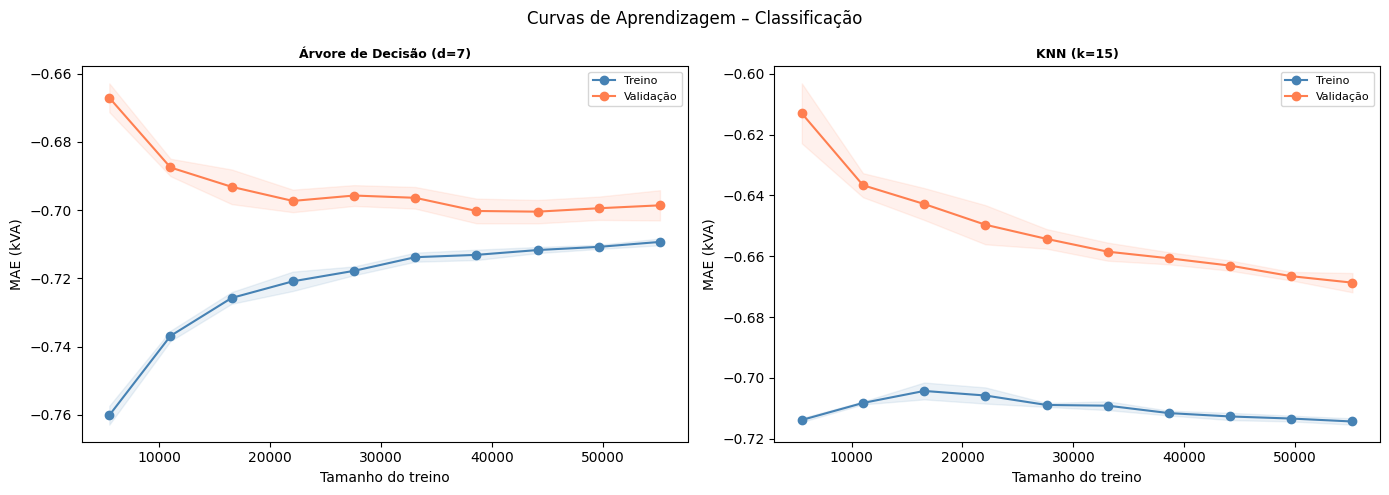

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(DecisionTreeClassifier(max_depth=best_dc, random_state=SEED), X_clf, y_clf,
        f'Árvore de Decisão (d={best_dc})', axes[0], scoring='accuracy')
plot_lc(KNeighborsClassifier(n_neighbors=best_knn), X_clf_sc, y_clf,
        f'KNN (k={best_knn})', axes[1], scoring='accuracy')
plt.suptitle('Curvas de Aprendizagem – Classificação', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_clf.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3.6 - Limitações e Estratégias de Melhoria

**Limitações dos dados:**
1. Variáveis IP (`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD`) são **agregadas ao nível do concelho** e atribuídas igualmente a todos os PTDs do mesmo município — introduz variabilidade artificial.
2. `Pot_Geracao_kW` (geração distribuída/solar) tem 97.5% de nulos — impede modelar o impacto crescente das energias renováveis no saldo de potência.
3. `PVE_PTD = 13.2 kW` é constante por PTD — não distingue zonas urbanas de alta densidade de zonas rurais com diferentes perfis de adoção de VE.

**Limitações dos modelos:**
4. SVM treinado em subsample (n=6000 de ~69000) por limitações computacionais — poder preditivo potencialmente subestimado.
5. O modelo OLS do TP1 (R²_adj=6.4%) confirmou que variáveis de IP e capacidade do PTD explicam pouco da variância ao nível agregado; ao nível do PTD individual os resultados deverão ser mais robustos.

**Estratégias de melhoria:**
- **Random Forest / XGBoost**: modelos ensemble para comparação com os modelos simples.
- **GridSearchCV**: tuning sistemático de hiperparâmetros (C, gamma, depth, criterion).
- **SMOTE**: oversampling se classes de `utilizRede` ficarem desbalanceadas.
- **Estratificação urbana/rural**: análise separada por Tipo Construtivo.
- **Variáveis temporais**: cruzamento com séries temporais de consumo para capturar sazonalidade.